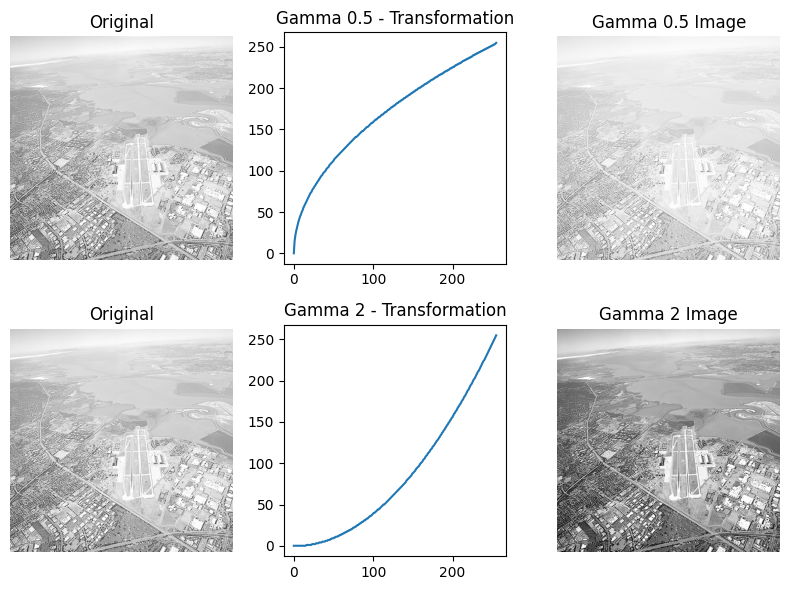

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

f = cv.imread("images/runway.png", cv.IMREAD_GRAYSCALE)

if f is None:
    raise ValueError("Image not loaded")

# Gamma 0.5 (brighten)
gamma = 0.5
t1 = np.array([(i/255.0) ** (gamma) * 255 for i in np.arange(0,256)]).astype(np.uint8)
g1 = cv.LUT(f, t1)

# Gamma 2 (darken)
gamma = 2
t2 = np.array([(i/255.0) ** (gamma) * 255 for i in np.arange(0,256)]).astype(np.uint8)
g2 = cv.LUT(f, t2)

fig, ax = plt.subplots(2,3, figsize=(8,6))

ax[0, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0, 0].set_title("Original")

ax[1, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title("Original")

x = np.arange(0, 256)

for a in ax.flatten():
    a.axis('off')

ax[0, 1].plot(x, t1)
ax[0, 1].set_title("Gamma 0.5 - Transformation")
ax[0, 1].axis('on')

ax[0, 2].imshow(g1, cmap='gray', vmin=0, vmax=255)
ax[0, 2].set_title("Gamma 0.5 Image")

ax[1, 1].plot(x, t2)
ax[1, 1].set_title("Gamma 2 - Transformation")
ax[1, 1].axis('on')

ax[1, 2].imshow(g2, cmap='gray', vmin=0, vmax=255)
ax[1, 2].set_title("Gamma 2 Image")

plt.tight_layout()
plt.show()

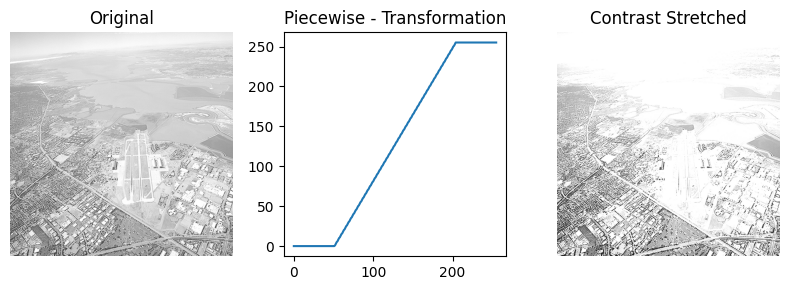

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread("images/runway.png", cv.IMREAD_GRAYSCALE)

if f is None:
    raise ValueError("Image not loaded")

# As r is in range [0,1] we have to multiply by 255
r1 = int(0.2 * 255)
r2 = int(0.8 * 255)

# Build LUT
t = np.zeros(256, dtype=np.uint8)

for i in range(256):
    if i < r1:
        t[i] = 0
    elif i <= r2:
        t[i] = int((i - r1) / (r2 - r1) * 255)
    else:
        t[i] = 255

# Apply transformation
g = cv.LUT(f, t)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(8,3))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original")

ax[1].plot(np.arange(0, 256), t)
ax[1].set_title("Piecewise - Transformation")

ax[2].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[2].set_title("Contrast Stretched")

for a in ax.flatten():
    a.axis('off')

ax[1].axis('on')

plt.tight_layout()
plt.show()

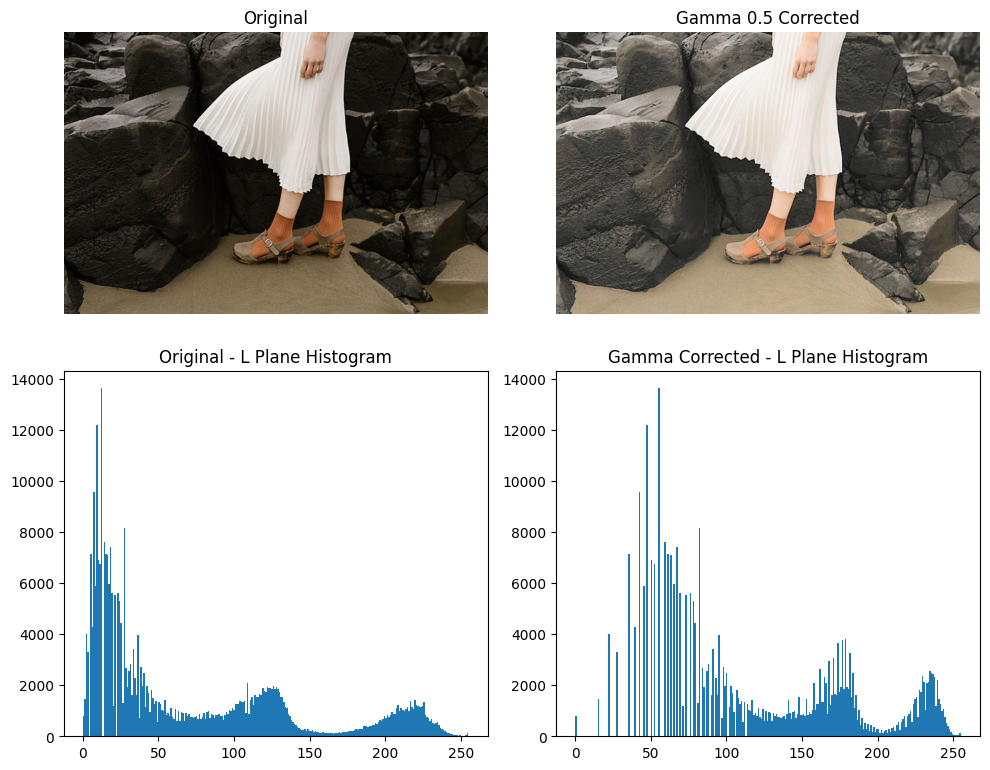

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv.imread("images/highlights_and_shadows.jpg")   # change path
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert to LAB
lab = cv.cvtColor(img, cv.COLOR_RGB2LAB)

L, a, b = cv.split(lab)

# Choose gamma
gamma = 0.5   # <1 brighten, >1 darken

L_new = (np.power(L / 255.0, gamma) * 255).astype(np.uint8)

# Merge channels
lab_new = cv.merge([L_new, a, b])

# Convert back to RGB
img_new = cv.cvtColor(lab_new, cv.COLOR_LAB2RGB)

# -------------------------
# Plot images
# -------------------------
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0,0].imshow(img)
ax[0,0].set_title("Original")

ax[0,1].imshow(img_new)
ax[0,1].set_title(f"Gamma {gamma} Corrected")

# -------------------------
# Histograms
# -------------------------
ax[1,0].hist(L.ravel(), bins=256, range=(0,255))
ax[1,0].set_title("Original - L Plane Histogram")

ax[1,1].hist(L_new.ravel(), bins=256, range=(0,255))
ax[1,1].set_title("Gamma Corrected - L Plane Histogram")

for a in ax.flatten():
    a.axis('off')

# Keep histogram axes visible
ax[1,0].axis('on')
ax[1,1].axis('on')

plt.tight_layout()
plt.show()

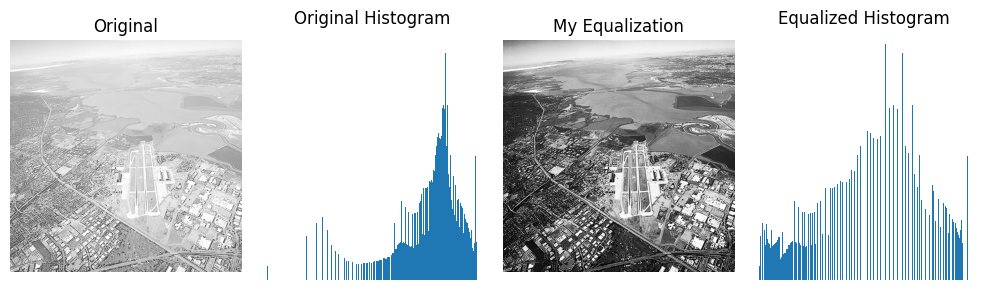

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def my_hist_equalization(img):
    # Flatten image to 1D
    flat = img.flatten()

    # Step 1: Compute histogram
    hist = np.zeros(256, dtype=int)
    for pixel in flat:
        hist[pixel] += 1

    # Step 2: Normalize histogram (PDF)
    total_pixels = img.shape[0] * img.shape[1]
    pdf = hist / total_pixels

    # Step 3: Compute CDF
    cdf = np.cumsum(pdf)

    # Step 4: Map old values → new values
    equalized_values = np.floor(255 * cdf).astype(np.uint8)

    # Step 5: Replace pixels
    equalized_img = equalized_values[flat]

    # Reshape back to original image shape
    equalized_img = equalized_img.reshape(img.shape)

    return equalized_img

f = cv.imread("images/runway.png", cv.IMREAD_GRAYSCALE)

if f is None:
    raise ValueError("Image not loaded")

eq_img = my_hist_equalization(f)

fig, ax = plt.subplots(1, 4, figsize=(10, 3))

ax[0].set_title('Original')
ax[0].imshow(f, cmap='gray')

ax[1].set_title('Original Histogram')
ax[1].hist(f.ravel(), bins=256, range=(0,255))

ax[2].set_title('My Equalization')
ax[2].imshow(eq_img, cmap='gray')
ax[2].axis('off')

ax[3].set_title('Equalized Histogram')
ax[3].hist(eq_img.ravel(), bins=256, range=(0,255))

for a in ax.flatten():
    a.axis('off')

plt.tight_layout()
plt.show()

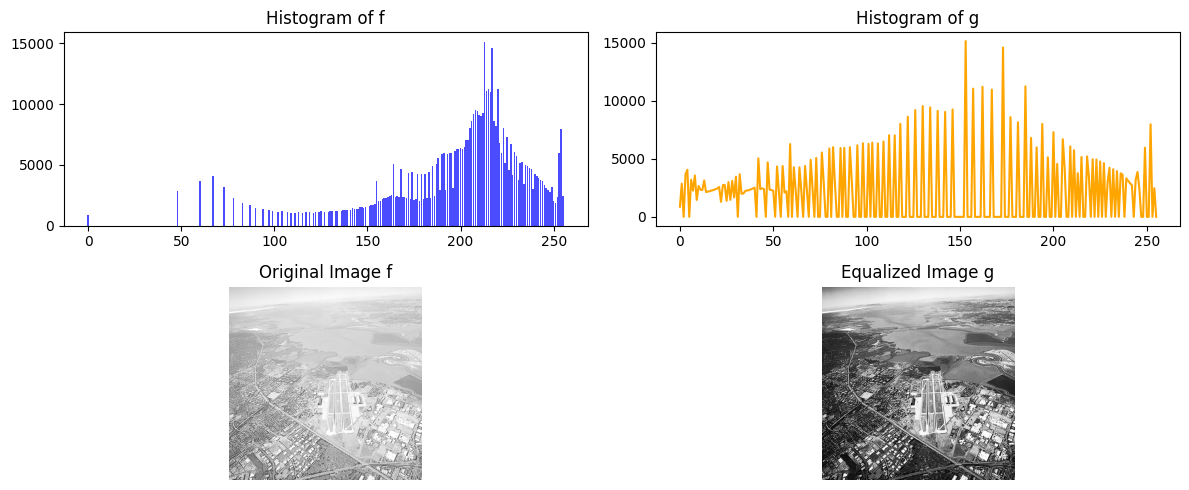

In [28]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

f = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
if f is None:
    raise ValueError("Image not loaded")

M, N = f.shape[0], f.shape[1]
L = 255

hist_f = np.histogram(f.ravel(), bins=256, range=(0, 255))[0]
cum_hist_f = np.cumsum(hist_f)

t = np.array([(L-1)/(M*N) * cum_hist_f[k] for k in range(256)], dtype=np.uint8)
g = t[f]

hist_g = np.histogram(g.ravel(), bins=256, range=(0, 255))[0]

fig, ax = plt.subplots(2, 2, figsize=(12, 5))
ax[0, 0].bar(range(256), hist_f, color='blue', alpha=0.7)
ax[0, 0].set_title('Histogram of f')

ax[0, 1].plot(range(256), hist_g, color='orange')
ax[0, 1].set_title('Histogram of g')

ax[1, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title('Original Image f')

ax[1, 1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1, 1].set_title('Equalized Image g')

ax[1, 0].axis('off')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

Otsu Threshold = 98.0


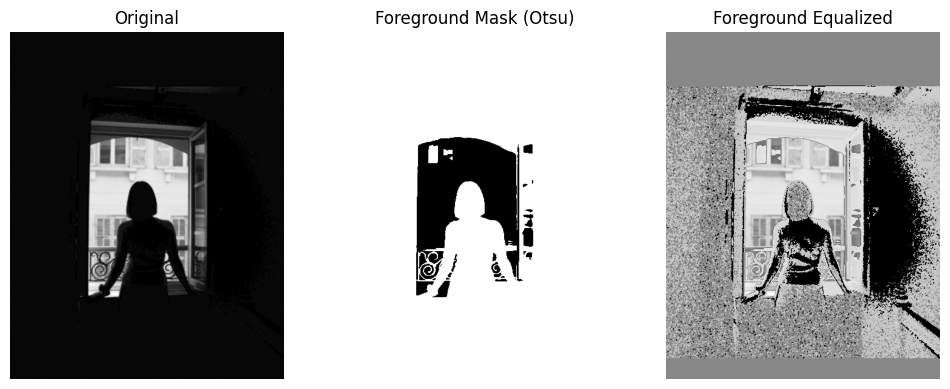

In [53]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

f = cv.imread('images/figure3.png', cv.IMREAD_GRAYSCALE)
if f is None:
    raise ValueError("Image not loaded")

# Otsu threshold
ret, mask = cv.threshold(f, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

print("Otsu Threshold =", ret)

# Equalize whole image first
equalized = cv.equalizeHist(f)

# Replace ONLY foreground pixels
result = f.copy()
result[mask == 255] = equalized[mask == 255]

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].set_title('Original')
ax[0].imshow(f, cmap='gray')

ax[1].set_title('Foreground Mask (Otsu)')
ax[1].imshow(mask, cmap='gray')

ax[2].set_title('Foreground Equalized')
ax[2].imshow(result, cmap='gray')

for a in ax:
    a.axis('off')

plt.show()